In [1]:
import numpy as np 
import torch 
import torch.nn as nn 
from torchsummary import summary
from torch.utils.data import DataLoader , TensorDataset
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.EMNIST(
    root='./data',
    split='balanced',   # 👈 choose split
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.EMNIST(
    root='./data',
    split='balanced',
    train=False,
    download=True,
    transform=transform
)

train_loader=DataLoader( train_data ,batch_size=600 ,shuffle=True , drop_last=True )
test_loader=DataLoader(test_data , batch_size=len(test_data) , shuffle=False )






100%|██████████| 562M/562M [00:07<00:00, 80.1MB/s] 


In [3]:
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 20, kernel_size=3, stride=1, padding=1) #size will be 14 , 14
        self.bn1   = nn.BatchNorm2d(20)
        self.conv2 = nn.Conv2d(20, 30, kernel_size=3, stride=1, padding=1)#size will be 7 , 7
        self.bn2   = nn.BatchNorm2d(30)
        self.FF1=nn.Linear(30*7*7,200)
        self.FF2=nn.Linear(200 , 47)
        
    def forward(self , x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        
        x = torch.flatten(x, 1)
        
        x=F.relu(self.FF1(x))
        x=(self.FF2(x))
        
        return x
    

            
            
        
    

In [4]:
model=CNNmodel()
lossfn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.005)

In [5]:
# a function that trains the model

def function2trainTheModel(model , lossfn , optimizer):

  # number of epochs
  numepochs = 20

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []


  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    model.train()
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = model(X)
      loss = lossfn(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    model.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = model(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,testAcc,losses


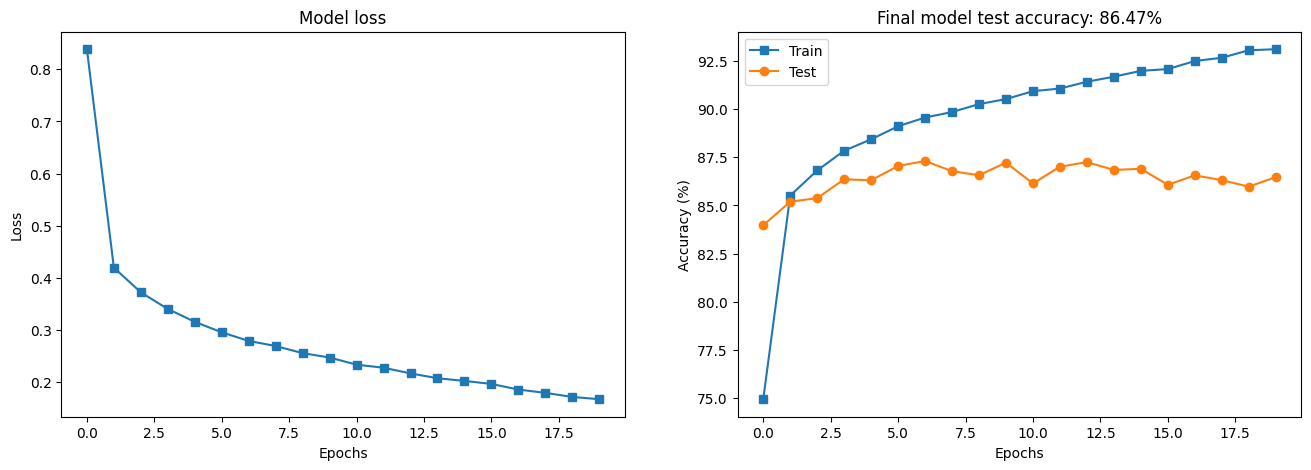

In [6]:
trainAcc,testAcc,losses=function2trainTheModel(model , lossfn , optimizer)
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()